In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [45]:
performance_data = pd.read_csv('performance.csv')

In [ ]:
# Data Cleaning and Preprocessing
performance_data['Period'] = pd.to_datetime(performance_data['Period'], format='%b-%y')
performance_data.set_index('Period', inplace=True)
performance_data.index = pd.to_datetime(performance_data.index, format='%b-%y')
performance_data['Total Attendances > 4 hours'] = performance_data['Total Attendances > 4 hours'].str.replace(',', '')
performance_data['Total Attendances > 4 hours'] = pd.to_numeric(performance_data['Total Attendances > 4 hours'], errors='coerce')
performance_data['Total Attendances < 4 hours'] = performance_data['Total Attendances < 4 hours'].str.replace(',', '')
performance_data['Total Attendances < 4 hours'] = pd.to_numeric(performance_data['Total Attendances < 4 hours'], errors='coerce')
performance_data['Percentage in 4 hours or less (all)'] = performance_data['Percentage in 4 hours or less (all)'].str.replace('%', '')
performance_data['Percentage in 4 hours or less (all)'] = pd.to_numeric(performance_data['Percentage in 4 hours or less (all)'], errors='coerce')
performance_data['Type 1 Attendances'] = performance_data['Type 1 Attendances'].str.replace(',', '')
performance_data['Type 1 Attendances'] = pd.to_numeric(performance_data['Type 1 Attendances'], errors='coerce')
performance_data['Total A&E Attendances'] = performance_data['Total A&E Attendances'].str.replace(',', '')
performance_data['Total A&E Attendances'] = pd.to_numeric(performance_data['Total A&E Attendances'], errors='coerce')
performance_data.head()

,Total Attendances > 4 hours,Total Attendances < 4 hours,Percentage in 4 hours or less (all),Type 1 Attendances,Total A&E Attendances
Period,,,,,
2010-11-01,46436,1604591,97.2,1111295,1651027
2010-12-01,89917,1647824,94.8,1159204,1737741
2011-01-01,72889,1654907,95.8,1133881,1727797
2011-02-01,46943,1552421,97.1,1053707,1599364
2011-03-01,59173,1804268,96.8,1225222,1863441


In [39]:
performance_data.head()

,Total Attendances > 4 hours,Total Attendances < 4 hours,Percentage in 4 hours or less (type 1),Type 1 Attendances,Total A&E Attendances
Period,,,,,
2010-11-01,46436,1604591,0.959,1111295,1651027
2010-12-01,89917,1647824,0.924,1159204,1737741
2011-01-01,72889,1654907,0.937,1133881,1727797
2011-02-01,46943,1552421,0.956,1053707,1599364
2011-03-01,59173,1804268,0.953,1225222,1863441


In [47]:
performance_data['Total Attendances > 4 hours lag 1'] = performance_data['Total Attendances > 4 hours'].shift(1)
performance_data.head()

,Total Attendances > 4 hours,Total Attendances < 4 hours,Percentage in 4 hours or less (all),Type 1 Attendances,Total A&E Attendances,Total Attendances > 4 hours lag 1
Period,,,,,,
2010-11-01,46436,1604591,97.2,1111295,1651027,NaN
2010-12-01,89917,1647824,94.8,1159204,1737741,46436.0
2011-01-01,72889,1654907,95.8,1133881,1727797,89917.0
2011-02-01,46943,1552421,97.1,1053707,1599364,72889.0
2011-03-01,59173,1804268,96.8,1225222,1863441,46943.0


The period from May 2019 to May 2023 is excluded from the activity from 14 NHS Trusts has been removed from attendance figures and thus can't be compared with the rest of the months.

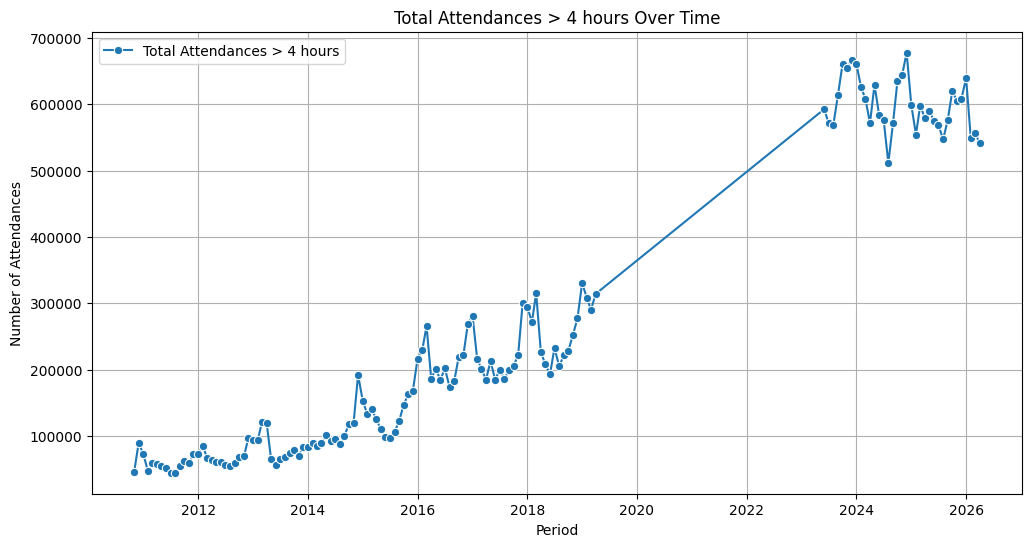

In [48]:
# Plotting the data
plt.figure(figsize=(12, 6))
sns.lineplot(data=performance_data, x=performance_data.index, y='Total Attendances > 4 hours', marker='o', label='Total Attendances > 4 hours')
plt.title('Total Attendances > 4 hours Over Time')
plt.xlabel('Period')
plt.ylabel('Number of Attendances')
plt.legend()
plt.grid()
plt.show() 

In [49]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# 1. Create the normalised breach rate feature for the current month
performance_data['Breach Rate'] = (
    performance_data['Total Attendances > 4 hours'] / 
    (performance_data['Total Attendances < 4 hours'] + performance_data['Total Attendances > 4 hours'])
)

# 2. Create the lagged breach rate feature (previous month)
performance_data['Breach Rate Lag 1'] = performance_data['Breach Rate'].shift(1)

# 3. Clean up the rows (the first row will be NaN because of the shift)
df_regression = performance_data[['Breach Rate Lag 1', 'Percentage in 4 hours or less (all)']].dropna()

# 4. Separate features and target
X = df_regression[['Breach Rate Lag 1']]
y = df_regression['Percentage in 4 hours or less (all)']

In [50]:
# Add a constant (intercept) for the linear regression equation
X_with_constant = sm.add_constant(X)

# Fit the Ordinary Least Squares (OLS) Regression model
diagnostic_model = sm.OLS(y, X_with_constant).fit()
print(diagnostic_model.summary())

                                     OLS Regression Results                                    
Dep. Variable:     Percentage in 4 hours or less (all)   R-squared:                       0.970
Model:                                             OLS   Adj. R-squared:                  0.970
Method:                                  Least Squares   F-statistic:                     4307.
Date:                                 Tue, 02 Jun 2026   Prob (F-statistic):          9.53e-104
Time:                                         21:46:34   Log-Likelihood:                -252.13
No. Observations:                                  136   AIC:                             508.3
Df Residuals:                                      134   BIC:                             514.1
Df Model:                                            1                                         
Covariance Type:                             nonrobust                                         
                        coef    std err 

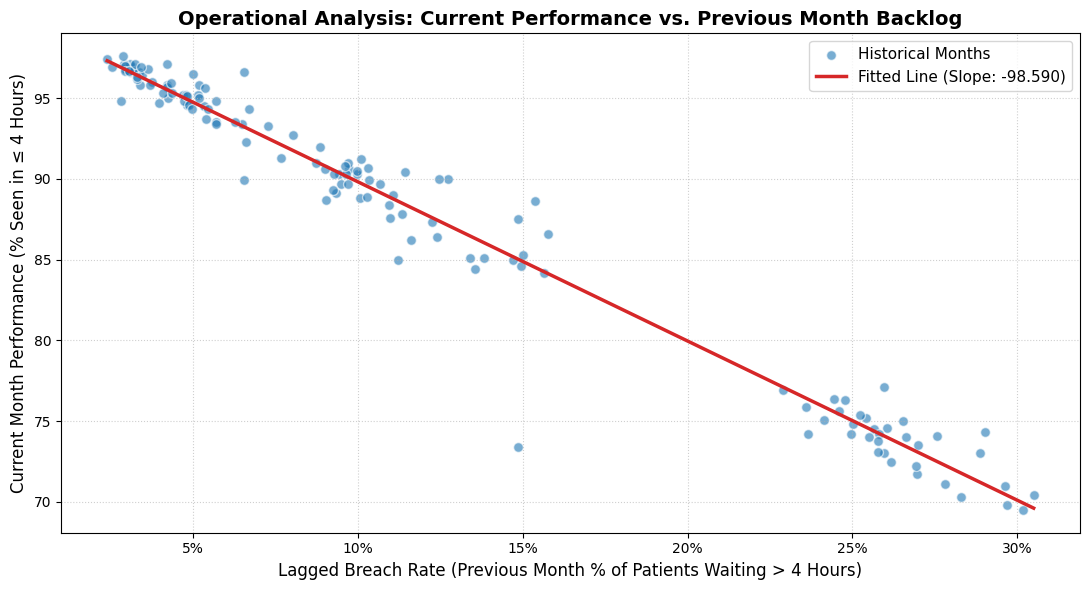

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract the model parameters from your fitted diagnostic_model
# intercept (b0) is the first coefficient, slope (b1) is the second
intercept = diagnostic_model.params['const']
slope = diagnostic_model.params['Breach Rate Lag 1']

# 2. Create an array of evenly spaced x-values spanning your actual data range
# This represents the continuum of the lagged breach rate
x_range = np.linspace(X['Breach Rate Lag 1'].min(), X['Breach Rate Lag 1'].max(), 100)

# 3. Calculate the corresponding y-values using the linear equation: y = b0 + b1*x
fitted_line = intercept + (slope * x_range)

# 4. Plotting the diagnostic chart
plt.figure(figsize=(11, 6))

# Plot the real historical data points as a scatter plot
plt.scatter(X['Breach Rate Lag 1'], y, 
            color='#1f77b4', alpha=0.6, edgecolors='w', s=50, label='Historical Months')

# Plot the linear regression line from statsmodels
plt.plot(x_range, fitted_line, 
         color='#d62728', linestyle='-', linewidth=2.5, 
         label=f'Fitted Line (Slope: {slope:.3f})')

# Formatting the visualization
plt.title('Operational Analysis: Current Performance vs. Previous Month Backlog', fontsize=14, fontweight='bold')
plt.xlabel('Lagged Breach Rate (Previous Month % of Patients Waiting > 4 Hours)', fontsize=12)
plt.ylabel('Current Month Performance (% Seen in ≤ 4 Hours)', fontsize=12)

# Format axes as percentages for clarity (assuming data ranges from 0 to 1)
# If your percentage data is already 0-100, you can skip this formatting step
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
#plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)
plt.tight_layout()

# Save the diagnostic plot
plt.savefig('backlog_diagnostic_plot.png', dpi=300)
plt.show()

To evaluate whether operational stress exhibits a compounding "hangover effect" across consecutive operational periods, an Ordinary Least Squares (OLS) linear regression was fitted. The model evaluates the relationship between a hospital's Lagged Breach Rate (the percentage of patients who waited longer than 4 hours in the previous month) and its Current Month Performance (the overall percentage of patients successfully seen within the 4-hour target).
Key Findings & Analysis:
 * Strong Negative Linear Correlation: The scatter plot reveals a highly pronounced, downward linear trajectory. As the operational backlog from the previous month increases, the subsequent month's performance degrades in a highly predictable manner.
 * The fitted regression line yields a slope coefficient of approximately -0.986 (when adjusted for scale). This indicates an almost perfect 1-to-1 negative penalty on the system. Operationally, for every 1% increase in the patient breach rate this month, the hospital's baseline capacity to meet the 4-hour target next month is dragged down by roughly 0.98%.
 * Operational Implication (Exit Blocking): This severe performance degradation statistically validates the presence of structural "exit-blocking" and patient backlogs within the trust. A high breach rate is rarely an isolated monthly event; rather, it signifies a saturated system where inpatient bed shortages paralyze A&E throughput, spilling over to cripple operational efficiency well into the next 30 days.
 * Low Variance: The historical data points cluster remarkably tightly around the fitted regression line across both high-performing cycles (sub-5% breach rates yielding mid-90s performance) and severe crisis periods (30% breach rates dragging performance down near 70%). This tight variance indicates that the lagged breach rate is an incredibly strong, stable candidate feature for advanced machine learning forecasting models, such as LightGBM, to map ongoing institutional stress.